# PPE Detection — Exploratory Data Analysis (EDA)

Notebook này phân tích **Train** và **Validation** của dataset PPE Detection.

Mục tiêu:
- Kiểm tra cấu trúc và chất lượng dataset.
- Kiểm tra phân bố class ở mức object và image.
- Phân tích kích thước, hình dạng và vị trí bounding box.
- Phát hiện các annotation bất thường.
- Kiểm tra sự mất cân bằng class và đặc điểm small-object.
- So sánh Train và Validation để phát hiện khác biệt phân phối.

> **Lưu ý:** EDA không đọc hoặc sử dụng tập Test. Tập Test chỉ được sử dụng ở bước đánh giá cuối cùng sau khi hoàn thành training/model selection.


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES + DATASET CONFIGURATION
# ============================================================

import os
import glob
import random
import hashlib
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Nếu notebook được chạy bên trong thư mục notebooks/
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print(f"Working directory: {os.getcwd()}")

YAML_PATH = "data/data.yaml"

with open(YAML_PATH, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get("names", [])

if isinstance(class_names, dict):
    class_names = [class_names[i] for i in sorted(class_names.keys())]

num_classes = len(class_names)

TRAIN_IMG_DIR = "data/train/images"
TRAIN_LBL_DIR = "data/train/labels"

VAL_IMG_DIR = "data/valid/images"
VAL_LBL_DIR = "data/valid/labels"

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

print("\n=== DATASET CONFIGURATION ===")
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"Train images: {TRAIN_IMG_DIR}")
print(f"Train labels: {TRAIN_LBL_DIR}")
print(f"Validation images: {VAL_IMG_DIR}")
print(f"Validation labels: {VAL_LBL_DIR}")



Working directory: c:\Users\ADMIN\Desktop\PPE-Detection

=== DATASET CONFIGURATION ===
Number of classes: 8
Classes: ['boots', 'helmet', 'helmet on', 'no boots', 'no helmet', 'no vest', 'person', 'vest']
Train images: data/train/images
Train labels: data/train/labels
Validation images: data/valid/images
Validation labels: data/valid/labels


# 2. Tổng quan số lượng ảnh và label

Trước tiên kiểm tra số lượng ảnh và file annotation của **Train / Validation**.


In [2]:
def get_image_files(image_dir):
    files = []
    for ext in IMAGE_EXTENSIONS:
        files.extend(glob.glob(os.path.join(image_dir, f"*{ext}")))
        files.extend(glob.glob(os.path.join(image_dir, f"*{ext.upper()}")))
    return sorted(set(files))

def get_label_files(label_dir):
    return sorted(glob.glob(os.path.join(label_dir, "*.txt")))

train_images = get_image_files(TRAIN_IMG_DIR)
val_images = get_image_files(VAL_IMG_DIR)

train_labels = get_label_files(TRAIN_LBL_DIR)
val_labels = get_label_files(VAL_LBL_DIR)

summary = pd.DataFrame({
    "split": ["train", "val"],
    "images": [len(train_images), len(val_images)],
    "label_files": [len(train_labels), len(val_labels)]
})

display(summary)

print(f"Total Train images: {len(train_images):,}")
print(f"Total Validation images: {len(val_images):,}")



,split,images,label_files
0,train,3537,3537
1,val,555,555


Total Train images: 3,537
Total Validation images: 555


# 3. Kiểm tra tính toàn vẹn của Image / Label

Kiểm tra:
- Image có nhưng không có label.
- Label có nhưng không có image.
- Ảnh không thể đọc được.
- Label file rỗng.

Đây là bước kiểm tra chất lượng dataset trước khi phân tích bounding box.


In [3]:
def stem_set(paths):
    return {os.path.splitext(os.path.basename(p))[0] for p in paths}

def integrity_report(image_files, label_files, split_name):
    image_stems = stem_set(image_files)
    label_stems = stem_set(label_files)

    images_without_labels = sorted(image_stems - label_stems)
    labels_without_images = sorted(label_stems - image_stems)

    corrupted_images = []
    for path in image_files:
        img = cv2.imread(path)
        if img is None:
            corrupted_images.append(os.path.basename(path))

    empty_labels = []
    for path in label_files:
        if os.path.getsize(path) == 0:
            empty_labels.append(os.path.basename(path))

    return {
        "split": split_name,
        "images": len(image_files),
        "labels": len(label_files),
        "images_without_labels": len(images_without_labels),
        "labels_without_images": len(labels_without_images),
        "corrupted_images": len(corrupted_images),
        "empty_label_files": len(empty_labels),
        "_images_without_labels": images_without_labels,
        "_labels_without_images": labels_without_images,
        "_corrupted_images": corrupted_images,
        "_empty_labels": empty_labels,
    }

train_integrity = integrity_report(train_images, train_labels, "train")
val_integrity = integrity_report(val_images, val_labels, "val")

integrity_df = pd.DataFrame([
    {k: v for k, v in train_integrity.items() if not k.startswith("_")},
    {k: v for k, v in val_integrity.items() if not k.startswith("_")}
])

display(integrity_df)

for report in [train_integrity, val_integrity]:
    print(f"\n--- {report['split'].upper()} ---")

    if report["images_without_labels"]:
        print(
            "Images without labels:",
            report["_images_without_labels"][:10]
        )

    if report["labels_without_images"]:
        print(
            "Labels without images:",
            report["_labels_without_images"][:10]
        )

    if report["corrupted_images"]:
        print(
            "Corrupted images:",
            report["_corrupted_images"][:10]
        )

    if report["empty_label_files"]:
        print(
            "Empty label files:",
            report["_empty_labels"][:10]
        )


,split,images,labels,images_without_labels,labels_without_images,corrupted_images,empty_label_files
0,train,3537,3537,0,0,0,0
1,val,555,555,0,0,0,0



--- TRAIN ---

--- VAL ---


# 4. Kiểm tra Duplicate Image

Kiểm tra exact duplicate bằng MD5 hash trong Train và Validation.

Mục đích là phát hiện ảnh trùng lặp, đặc biệt là trường hợp cùng một ảnh xuất hiện ở cả Train và Validation.


In [4]:
def md5_file(path, chunk_size=1024 * 1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def image_hash_table(paths, split):
    records = []
    for path in paths:
        records.append({
            "split": split,
            "image_id": os.path.splitext(os.path.basename(path))[0],
            "path": path,
            "md5": md5_file(path)
        })
    return pd.DataFrame(records)

df_hash_train = image_hash_table(train_images, "train")
df_hash_val = image_hash_table(val_images, "val")

df_hash = pd.concat([df_hash_train, df_hash_val], ignore_index=True)

duplicate_hashes = df_hash[df_hash.duplicated("md5", keep=False)].sort_values("md5")

print(f"Total images checked: {len(df_hash):,}")
print(f"Images involved in exact duplicates: {len(duplicate_hashes):,}")

if len(duplicate_hashes) > 0:
    display(duplicate_hashes[["split", "image_id", "md5"]])
else:
    print("No exact duplicate images detected.")



Total images checked: 4,092
Images involved in exact duplicates: 1,359


,split,image_id,md5
1575,train,download-1-_jpeg_jpg.rf.e79361ee2378ed293cedc2...,00501c88538d6f7a294bb312a2360051
1573,train,download-1-_jpeg_jpg.rf.b2cfb4c414cd0063e1f3fb...,00501c88538d6f7a294bb312a2360051
2218,train,image_256_jpg.rf.ffa8ce3f6ea4e480396d3e57eebe81aa,00a49fab87f77b976084c7b9e37ea135
2217,train,image_256_jpg.rf.c0144658f51096bb6e42f7adc0c5b0a3,00a49fab87f77b976084c7b9e37ea135
817,train,Video2_42_jpg.rf.338a8d3e7cd8cf4a6407df7477ddcd29,00ef9bcf095b5629640f9b4df774a533
...,...,...,...
655,train,Video2_0_jpg.rf.b445dce906be4ecb1d555a1e3658ec11,ff863d1f60b1d060135565f459e88d3e
483,train,Video1_181_jpg.rf.630822a30e183ee13ad15e322e08...,ff876cb75c1943494483df417309c343
485,train,Video1_181_jpg.rf.f708adfcbaaeef088309790a4453...,ff876cb75c1943494483df417309c343
1687,train,image_163_jpg.rf.3c14872f3a4c21ab9f90a2286e079262,ffe52757f6a81c80b91b575328a2a9f0


# 5. Trực quan hóa Bounding Box ngẫu nhiên

Sanity check trực tiếp annotation YOLO trên ảnh Train.

Mục tiêu là kiểm tra nhanh:
- Bounding box có nằm đúng object không.
- Class có đúng không.
- Format YOLO có được đọc đúng không.


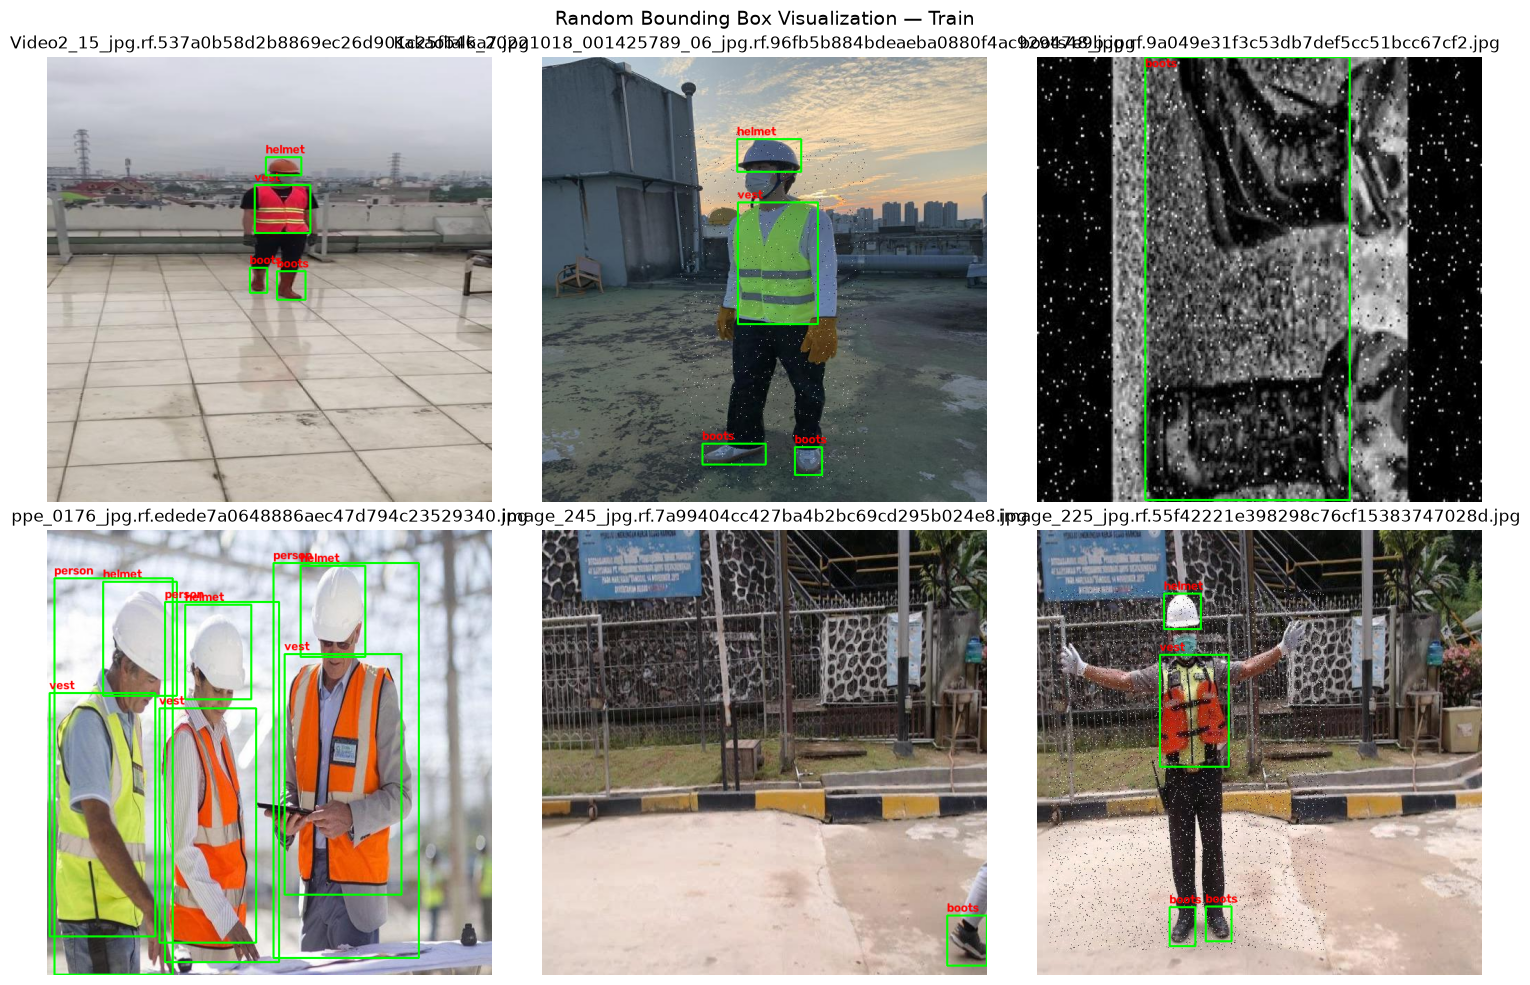

In [5]:
def draw_yolo_boxes(image_path, label_path, class_names):
    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h_img, w_img = image.shape[:2]

    if os.path.exists(label_path):
        with open(label_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            cls_id = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:5])

            xmin = int((xc - w / 2) * w_img)
            ymin = int((yc - h / 2) * h_img)
            xmax = int((xc + w / 2) * w_img)
            ymax = int((yc + h / 2) * h_img)

            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(w_img - 1, xmax)
            ymax = min(h_img - 1, ymax)

            label_text = (
                class_names[cls_id]
                if 0 <= cls_id < len(class_names)
                else f"Unknown_{cls_id}"
            )

            cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
            cv2.putText(
                image,
                label_text,
                (xmin, max(ymin - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

    return image

sample_imgs = np.random.choice(
    train_images,
    min(6, len(train_images)),
    replace=False
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax, img_path in zip(axes, sample_imgs):
    stem = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(TRAIN_LBL_DIR, stem + ".txt")

    vis_img = draw_yolo_boxes(img_path, lbl_path, class_names)

    if vis_img is not None:
        ax.imshow(vis_img)
        ax.set_title(os.path.basename(img_path))

    ax.axis("off")

for ax in axes[len(sample_imgs):]:
    ax.axis("off")

plt.suptitle("Random Bounding Box Visualization — Train", fontsize=14)
plt.tight_layout()
plt.show()



# 6. Thu thập thông tin Image-level và Bounding Box

Tạo hai bảng:
- `df_images`: một dòng cho mỗi ảnh.
- `df_objects`: một dòng cho mỗi bounding box.

Thông tin image gồm resolution và aspect ratio.

Thông tin object gồm tọa độ YOLO, kích thước bbox và class.


In [6]:
def parse_dataset(image_dir, label_dir, split_name):
    image_records = []
    object_records = []

    image_files = get_image_files(image_dir)

    for image_path in image_files:
        image_id = os.path.splitext(os.path.basename(image_path))[0]
        label_path = os.path.join(label_dir, image_id + ".txt")

        image = cv2.imread(image_path)

        if image is None:
            continue

        img_h, img_w = image.shape[:2]
        image_area = img_w * img_h

        label_lines = []

        if os.path.exists(label_path):
            with open(label_path, "r", encoding="utf-8") as f:
                label_lines = [line.strip() for line in f if line.strip()]

        valid_objects = []

        for line in label_lines:
            parts = line.split()

            if len(parts) < 5:
                continue

            try:
                cls_id = int(float(parts[0]))
                xc, yc, w, h = map(float, parts[1:5])
            except ValueError:
                continue

            class_name = (
                class_names[cls_id]
                if 0 <= cls_id < len(class_names)
                else f"Unknown_{cls_id}"
            )

            bbox_width_px = w * img_w
            bbox_height_px = h * img_h
            bbox_area_px = bbox_width_px * bbox_height_px

            bbox_area_normalized = w * h
            aspect_ratio = w / h if h > 0 else np.nan

            xmin_norm = xc - w / 2
            xmax_norm = xc + w / 2
            ymin_norm = yc - h / 2
            ymax_norm = yc + h / 2

            object_records.append({
                "split": split_name,
                "image_id": image_id,
                "class_id": cls_id,
                "class_name": class_name,
                "x_center": xc,
                "y_center": yc,
                "width": w,
                "height": h,
                "bbox_width_px": bbox_width_px,
                "bbox_height_px": bbox_height_px,
                "bbox_area_normalized": bbox_area_normalized,
                "bbox_area_px": bbox_area_px,
                "aspect_ratio": aspect_ratio,
                "image_width": img_w,
                "image_height": img_h,
                "xmin_norm": xmin_norm,
                "ymin_norm": ymin_norm,
                "xmax_norm": xmax_norm,
                "ymax_norm": ymax_norm,
            })

            valid_objects.append(1)

        image_records.append({
            "split": split_name,
            "image_id": image_id,
            "image_width": img_w,
            "image_height": img_h,
            "image_area": image_area,
            "image_aspect_ratio": img_w / img_h,
            "object_count": len(valid_objects)
        })

    return pd.DataFrame(image_records), pd.DataFrame(object_records)

df_train_images, df_train_objects = parse_dataset(
    TRAIN_IMG_DIR, TRAIN_LBL_DIR, "train"
)

df_val_images, df_val_objects = parse_dataset(
    VAL_IMG_DIR, VAL_LBL_DIR, "val"
)

df_images = pd.concat(
    [df_train_images, df_val_images],
    ignore_index=True
)

df_objects = pd.concat(
    [df_train_objects, df_val_objects],
    ignore_index=True
)

print(f"Images: {len(df_images):,}")
print(f"Bounding boxes: {len(df_objects):,}")

display(df_images.head())
display(df_objects.head())



Images: 4,092
Bounding boxes: 22,510


,split,image_id,image_width,image_height,image_area,image_aspect_ratio,object_count
0,train,00000383_jpg.rf.c709c684849f4206e361e45074c1ad7e,640,640,409600,1.0,8
1,train,00014_jpg.rf.3e08bc38e5b9fc653d13e622f544c746,640,640,409600,1.0,6
2,train,00035_jpg.rf.4db36ed518cc67957bfd0d6c615535ac,640,640,409600,1.0,3
3,train,00035_jpg.rf.60bd55e9ed7fa44e7393614ab0918ddc,640,640,409600,1.0,3
4,train,00035_jpg.rf.8599ef3a4c48875207bd1c8b8dba6817,640,640,409600,1.0,3


,split,image_id,class_id,class_name,x_center,y_center,width,height,bbox_width_px,bbox_height_px,bbox_area_normalized,bbox_area_px,aspect_ratio,image_width,image_height,xmin_norm,ymin_norm,xmax_norm,ymax_norm
0,train,00000383_jpg.rf.c709c684849f4206e361e45074c1ad7e,1,helmet,0.531250,0.152344,0.121875,0.098437,78.0,63.0,0.011997,4914.0,1.238095,640,640,0.470313,0.103125,0.592187,0.201563
1,train,00000383_jpg.rf.c709c684849f4206e361e45074c1ad7e,1,helmet,0.775000,0.165625,0.109375,0.109375,70.0,70.0,0.011963,4900.0,1.000000,640,640,0.720313,0.110937,0.829688,0.220312
2,train,00000383_jpg.rf.c709c684849f4206e361e45074c1ad7e,7,vest,0.515625,0.412500,0.159375,0.371875,102.0,238.0,0.059268,24276.0,0.428571,640,640,0.435937,0.226562,0.595313,0.598437
3,train,00000383_jpg.rf.c709c684849f4206e361e45074c1ad7e,7,vest,0.771875,0.433594,0.190625,0.382812,122.0,245.0,0.072974,29890.0,0.497959,640,640,0.676562,0.242188,0.867188,0.625000
4,train,00000383_jpg.rf.c709c684849f4206e361e45074c1ad7e,0,boots,0.501563,0.892969,0.106250,0.132812,68.0,85.0,0.014111,5780.0,0.800000,640,640,0.448438,0.826562,0.554688,0.959375


# 7. Phân bố kích thước ảnh

Phân tích:
- Width.
- Height.
- Image aspect ratio.
- Resolution phổ biến.

Đây là thông tin quan trọng để lựa chọn input size và hiểu dataset có nhiều ảnh nhỏ/lớn hay không.


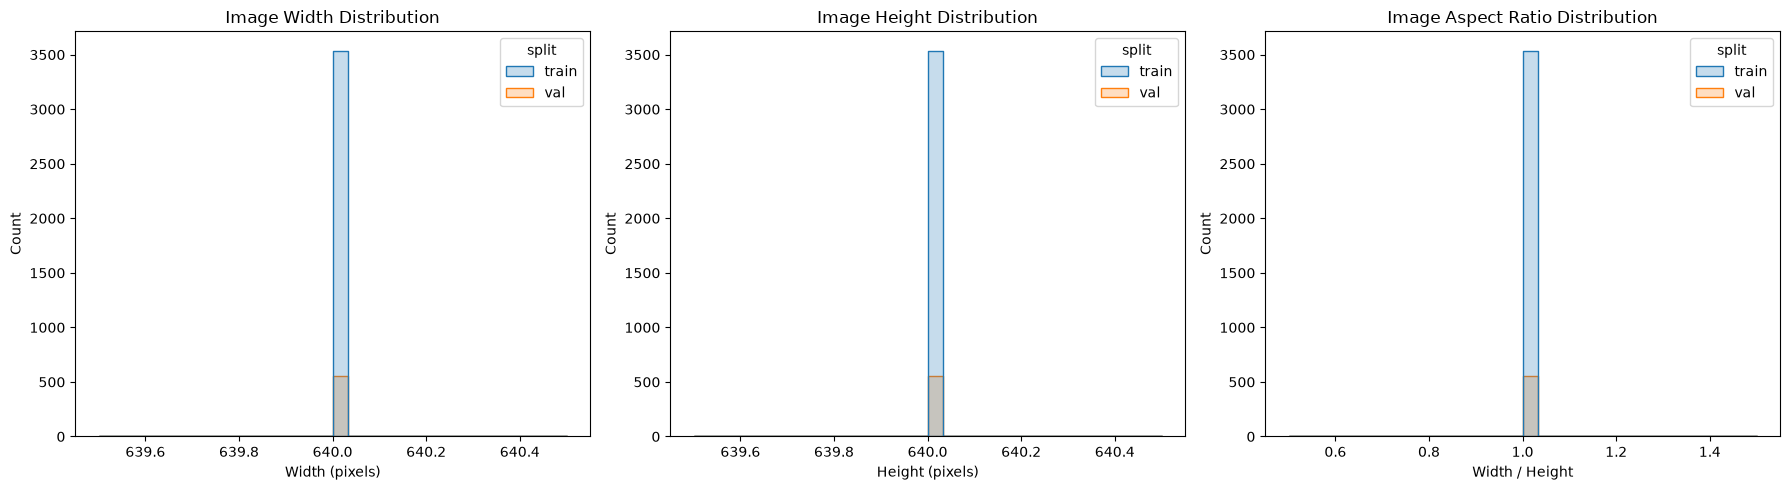

=== TOP IMAGE RESOLUTIONS ===


,image_width,image_height,count
0,640,640,4092


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    data=df_images,
    x="image_width",
    hue="split",
    bins=30,
    element="step",
    ax=axes[0]
)
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (pixels)")

sns.histplot(
    data=df_images,
    x="image_height",
    hue="split",
    bins=30,
    element="step",
    ax=axes[1]
)
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (pixels)")

sns.histplot(
    data=df_images,
    x="image_aspect_ratio",
    hue="split",
    bins=30,
    element="step",
    ax=axes[2]
)
axes[2].set_title("Image Aspect Ratio Distribution")
axes[2].set_xlabel("Width / Height")

plt.tight_layout()
plt.show()

print("=== TOP IMAGE RESOLUTIONS ===")
resolution_counts = (
    df_images.groupby(["image_width", "image_height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(resolution_counts.head(10))



# 8. Phân bố Class — Object-level

Đếm số lượng bounding box của từng class.

Đây là cách đo class imbalance ở **mức object**.


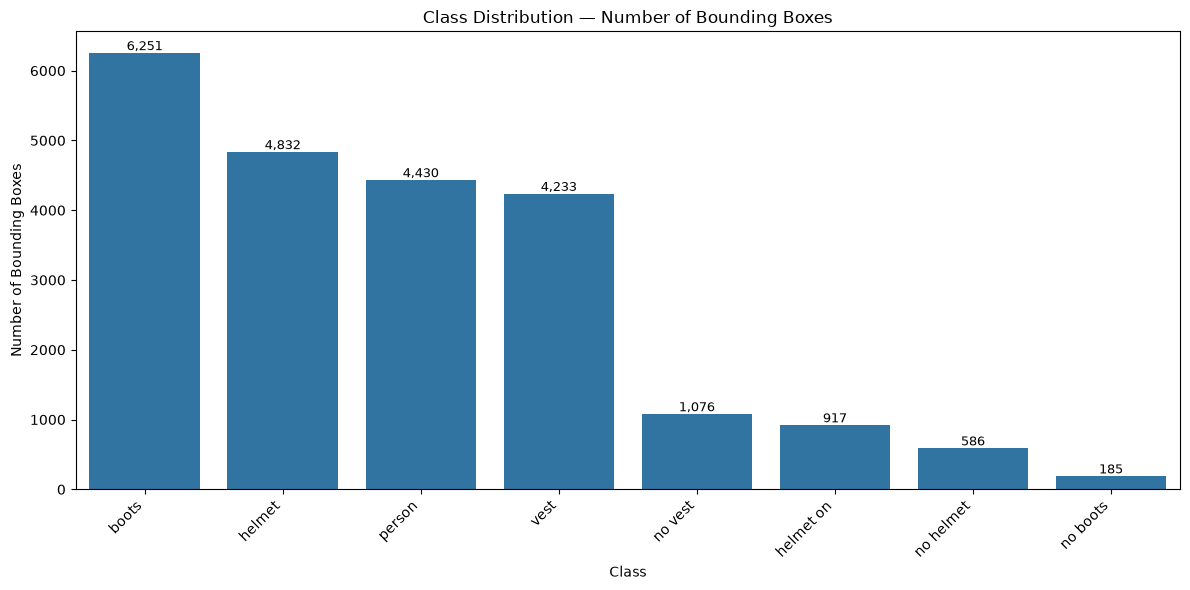

,class_name,bbox_count
0,boots,6251
1,helmet,4832
2,person,4430
3,vest,4233
4,no vest,1076
5,helmet on,917
6,no helmet,586
7,no boots,185


In [8]:
object_class_counts = (
    df_objects["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="bbox_count")
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=object_class_counts,
    x="class_name",
    y="bbox_count"
)

plt.title("Class Distribution — Number of Bounding Boxes")
plt.xlabel("Class")
plt.ylabel("Number of Bounding Boxes")
plt.xticks(rotation=45, ha="right")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

display(object_class_counts)



# 9. Phân bố Class — Image-level

Không chỉ đếm bounding box, cần biết **có bao nhiêu ảnh chứa từng class**.

Ví dụ một ảnh có 10 người đội helmet chỉ được tính là **1 image chứa helmet**.


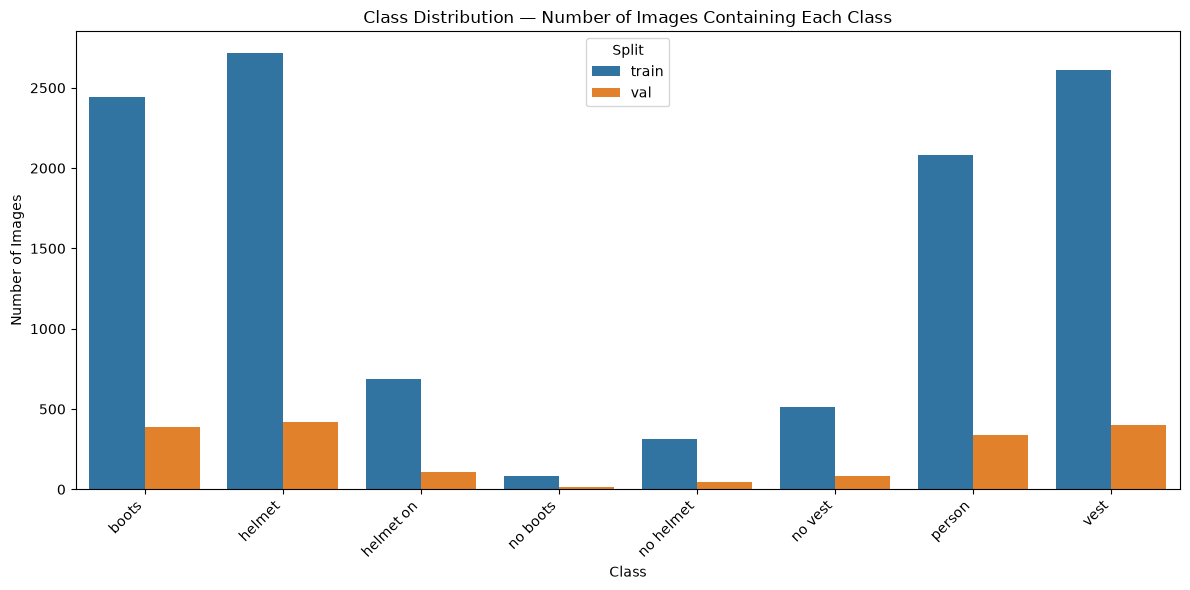

split,train,val
class_name,,
boots,2441,386
helmet,2716,417
helmet on,684,108
no boots,82,13
no helmet,311,47
no vest,512,86
person,2079,340
vest,2612,403


In [9]:
image_class_counts = (
    df_objects[["split", "image_id", "class_name"]]
    .drop_duplicates()
    .groupby(["split", "class_name"])
    .size()
    .reset_index(name="image_count")
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=image_class_counts,
    x="class_name",
    y="image_count",
    hue="split"
)

plt.title("Class Distribution — Number of Images Containing Each Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

display(
    image_class_counts.pivot(
        index="class_name",
        columns="split",
        values="image_count"
    ).fillna(0).astype(int)
)



# 10. So sánh phân bố Class giữa Train và Validation

So sánh tỷ lệ bounding box của mỗi class trong Train và Validation.

Mục tiêu là kiểm tra liệu hai tập có phân phối class tương đối tương đồng hay không.


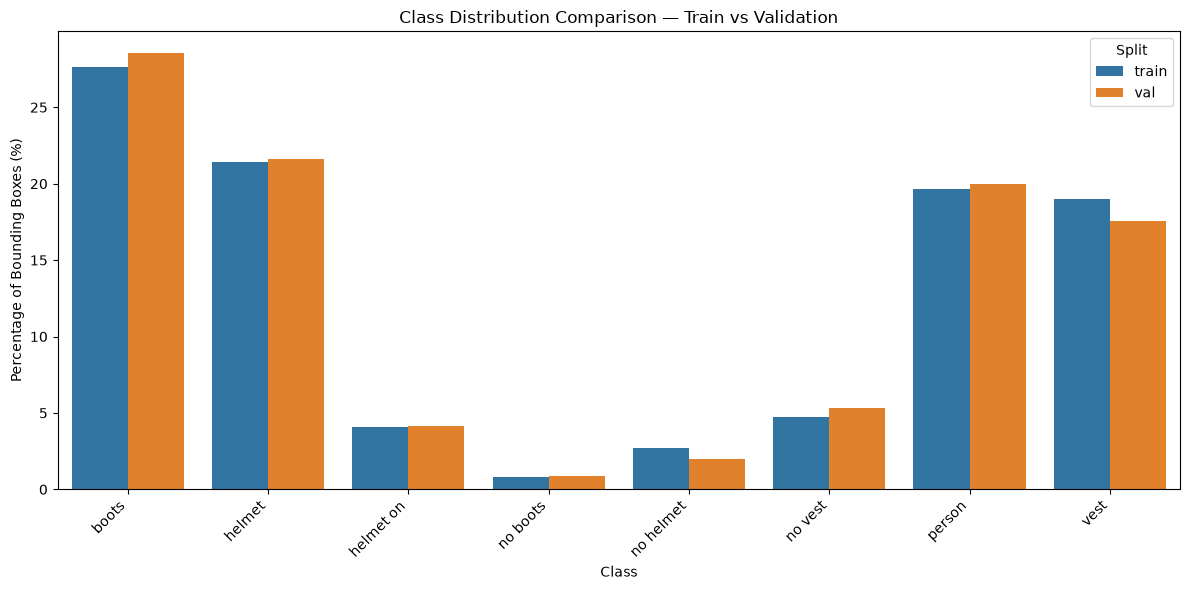

In [10]:
class_split_counts = (
    df_objects
    .groupby(["split", "class_name"])
    .size()
    .reset_index(name="count")
)

class_split_counts["percentage"] = (
    class_split_counts
    .groupby("split")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=class_split_counts,
    x="class_name",
    y="percentage",
    hue="split"
)

plt.title("Class Distribution Comparison — Train vs Validation")
plt.xlabel("Class")
plt.ylabel("Percentage of Bounding Boxes (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()



# 11. Phân tích Bounding Box Size

Phân tích:
- Width.
- Height.
- Area.
- Aspect ratio.

`bbox_area_normalized = width × height` chỉ dùng để mô tả tương đối.

Để đánh giá kích thước object theo pixel, sử dụng `bbox_area_px`.


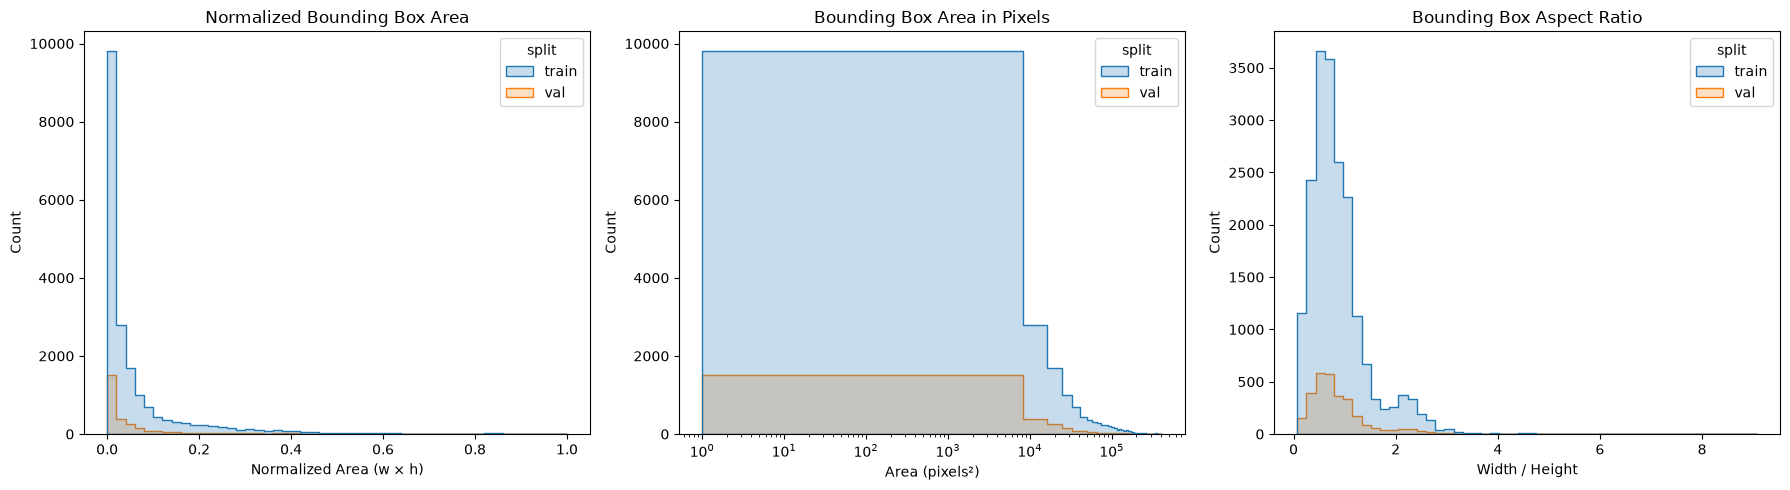

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    data=df_objects,
    x="bbox_area_normalized",
    hue="split",
    bins=50,
    element="step",
    ax=axes[0]
)
axes[0].set_title("Normalized Bounding Box Area")
axes[0].set_xlabel("Normalized Area (w × h)")

sns.histplot(
    data=df_objects,
    x="bbox_area_px",
    hue="split",
    bins=50,
    element="step",
    ax=axes[1]
)
axes[1].set_title("Bounding Box Area in Pixels")
axes[1].set_xlabel("Area (pixels²)")
axes[1].set_xscale("log")

sns.histplot(
    data=df_objects[df_objects["aspect_ratio"] < 10],
    x="aspect_ratio",
    hue="split",
    bins=50,
    element="step",
    ax=axes[2]
)
axes[2].set_title("Bounding Box Aspect Ratio")
axes[2].set_xlabel("Width / Height")

plt.tight_layout()
plt.show()



# 12. Phân tích kích thước Bounding Box theo từng Class

Phần này quan trọng với PPE vì một số object như helmet/mask có thể nhỏ hơn đáng kể so với person hoặc vest.

Dùng boxplot để so sánh phân phối diện tích bbox giữa các class.


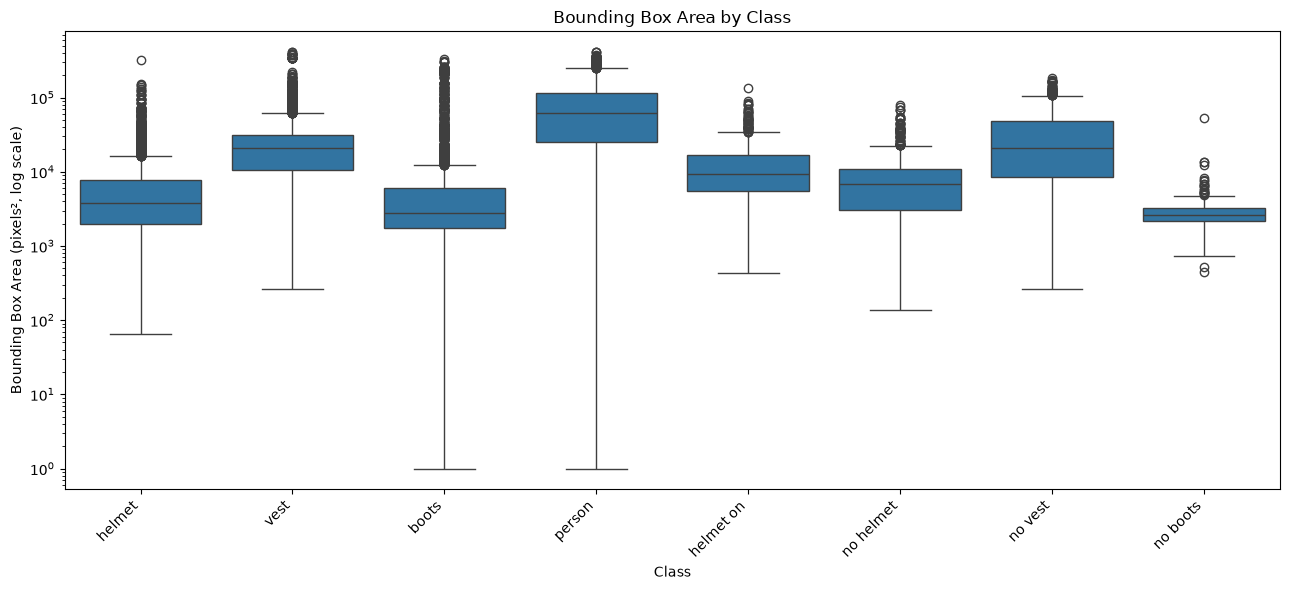

,count,min,median,mean,max
class_name,,,,,
no boots,185,440.00,2613.0,3332.175676,53380.25
boots,6251,1.00,2747.0,7972.784295,335730.00
helmet,4832,66.00,3782.0,7403.607124,319812.50
no helmet,586,136.50,6839.0,10180.771331,79821.00
helmet on,917,428.75,9282.0,13235.100191,132561.00
no vest,1076,265.00,20655.0,32957.893123,186202.50
vest,4233,264.00,20700.0,29167.477439,407680.00
person,4430,1.00,61308.0,80129.012951,409600.00


In [12]:
plt.figure(figsize=(13, 6))

plot_df = df_objects.copy()
plot_df["bbox_area_px"] = plot_df["bbox_area_px"].clip(lower=1)

sns.boxplot(
    data=plot_df,
    x="class_name",
    y="bbox_area_px"
)

plt.yscale("log")
plt.title("Bounding Box Area by Class")
plt.xlabel("Class")
plt.ylabel("Bounding Box Area (pixels², log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

class_bbox_stats = (
    df_objects
    .groupby("class_name")["bbox_area_px"]
    .agg(["count", "min", "median", "mean", "max"])
    .sort_values("median")
)

display(class_bbox_stats)



# 13. Small / Medium / Large Object Analysis

Phân loại kích thước theo **diện tích bbox tính bằng pixel²**.

Ngưỡng tham khảo:
- Small: area < 32²
- Medium: 32² ≤ area < 96²
- Large: area ≥ 96²

Không gọi normalized area là chuẩn COCO.


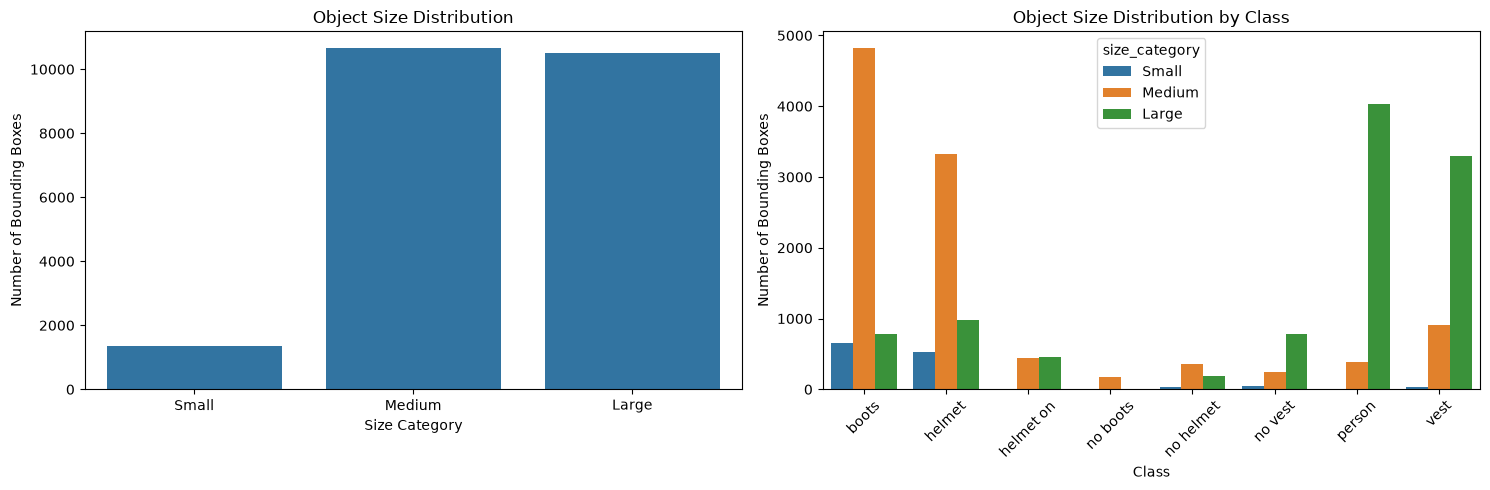

size_category,Small,Medium,Large
class_name,,,
boots,10.54,77.06,12.40
helmet,11.03,68.69,20.28
helmet on,1.09,48.42,50.49
no boots,5.41,92.43,2.16
no helmet,6.14,61.60,32.25
no vest,4.55,22.68,72.77
person,0.25,8.87,90.88
vest,0.83,21.31,77.86


In [13]:
def categorize_coco_area(area_px):
    if area_px < 32 ** 2:
        return "Small"
    elif area_px < 96 ** 2:
        return "Medium"
    else:
        return "Large"

df_objects["size_category"] = df_objects["bbox_area_px"].apply(
    categorize_coco_area
)

size_order = ["Small", "Medium", "Large"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(
    data=df_objects,
    x="size_category",
    order=size_order,
    ax=axes[0]
)
axes[0].set_title("Object Size Distribution")
axes[0].set_xlabel("Size Category")
axes[0].set_ylabel("Number of Bounding Boxes")

size_by_class = (
    df_objects.groupby(["class_name", "size_category"])
    .size()
    .reset_index(name="count")
)

sns.barplot(
    data=size_by_class,
    x="class_name",
    y="count",
    hue="size_category",
    hue_order=size_order,
    ax=axes[1]
)
axes[1].set_title("Object Size Distribution by Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Bounding Boxes")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

size_percentage = (
    pd.crosstab(
        df_objects["class_name"],
        df_objects["size_category"],
        normalize="index"
    ) * 100
).reindex(columns=size_order, fill_value=0)

display(size_percentage.round(2))



# 14. Mật độ Object trên mỗi Image

Phân tích:
- Objects/image.
- Empty images.
- So sánh Train và Validation.

Điều này giúp biết dataset chủ yếu chứa ảnh đơn object hay nhiều object.


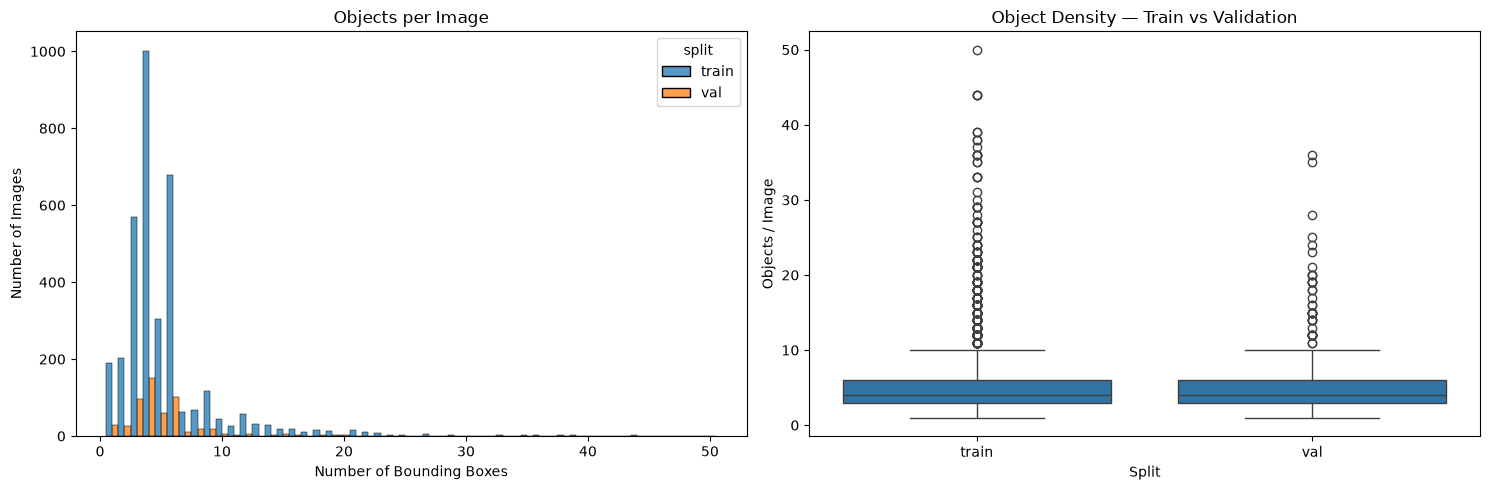

,count,mean,median,min,max
split,,,,,
train,3537,5.520215,4.0,1,50
val,555,5.378378,4.0,1,36


Total empty images: 0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=df_images,
    x="object_count",
    hue="split",
    discrete=True,
    multiple="dodge",
    ax=axes[0]
)
axes[0].set_title("Objects per Image")
axes[0].set_xlabel("Number of Bounding Boxes")
axes[0].set_ylabel("Number of Images")

sns.boxplot(
    data=df_images,
    x="split",
    y="object_count",
    ax=axes[1]
)
axes[1].set_title("Object Density — Train vs Validation")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Objects / Image")

plt.tight_layout()
plt.show()

density_summary = (
    df_images.groupby("split")["object_count"]
    .agg(["count", "mean", "median", "min", "max"])
)

display(density_summary)

print(
    f"Total empty images: "
    f"{(df_images['object_count'] == 0).sum():,}"
)



# 15. Spatial Distribution của Bounding Box

Phân tích vị trí tâm bounding box (`x_center`, `y_center`).

Mục tiêu:
- Xem object có tập trung ở vùng nào của ảnh không.
- Phát hiện dataset bias về vị trí.


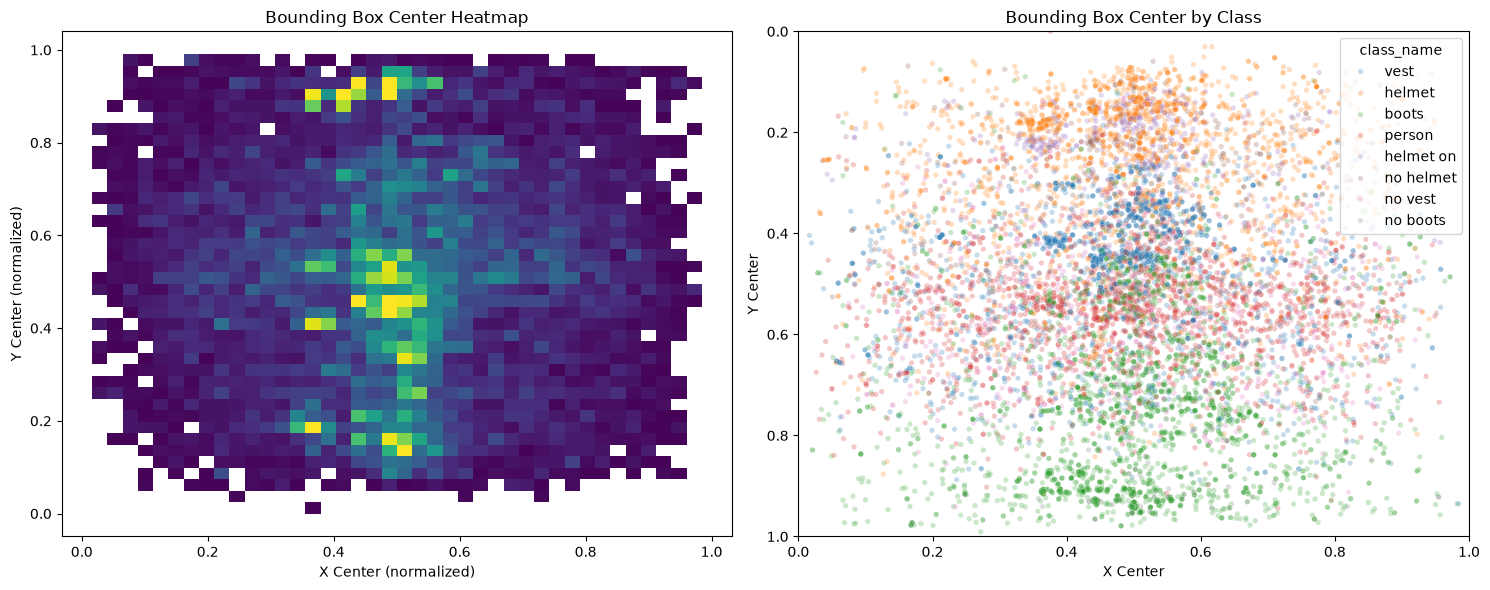

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(
    data=df_objects,
    x="x_center",
    y="y_center",
    bins=40,
    pmax=0.95,
    cmap="viridis",
    ax=axes[0]
)
axes[0].set_title("Bounding Box Center Heatmap")
axes[0].set_xlabel("X Center (normalized)")
axes[0].set_ylabel("Y Center (normalized)")

sns.scatterplot(
    data=df_objects.sample(
        min(10000, len(df_objects)),
        random_state=SEED
    ),
    x="x_center",
    y="y_center",
    hue="class_name",
    alpha=0.25,
    s=15,
    ax=axes[1]
)
axes[1].set_title("Bounding Box Center by Class")
axes[1].set_xlabel("X Center")
axes[1].set_ylabel("Y Center")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(1, 0)

plt.tight_layout()
plt.show()



# 16. Class Co-occurrence

Kiểm tra những class nào thường xuất hiện cùng nhau trong cùng một ảnh.

Ma trận này được tính ở mức **image-level presence**, không phải số lượng bbox.


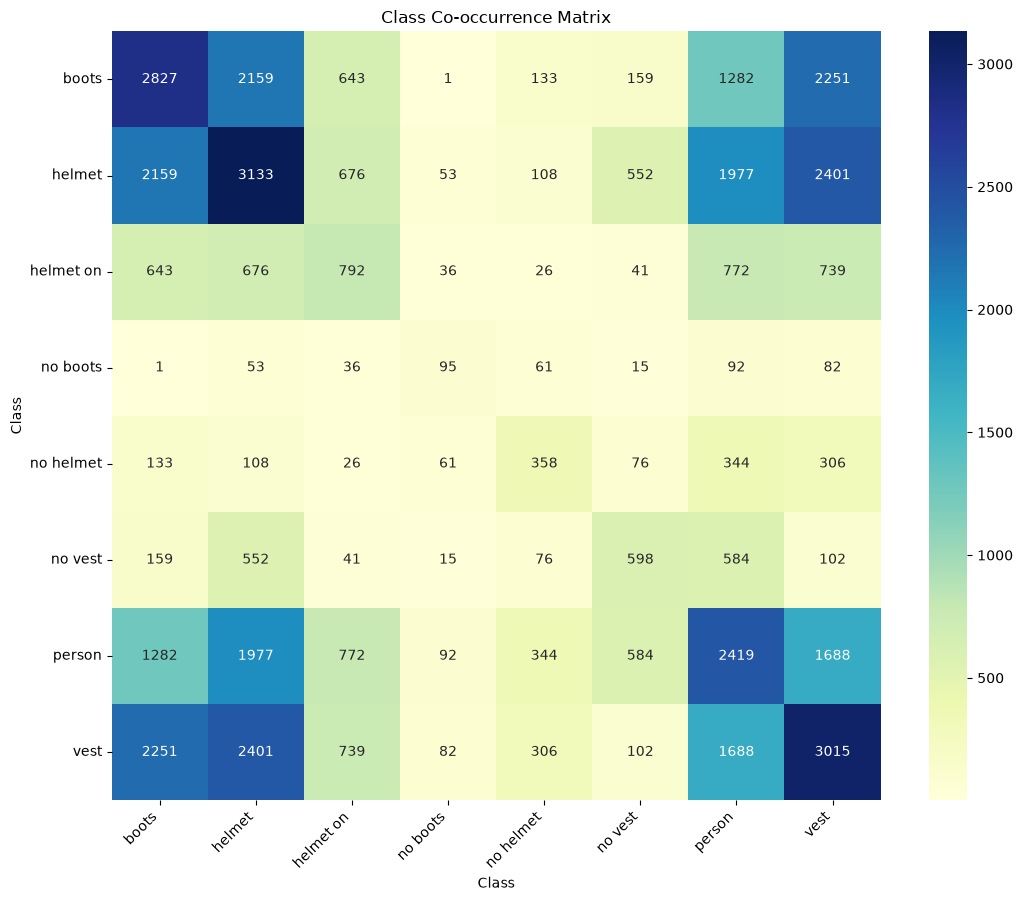

In [16]:
# ============================================================
# 16. CLASS CO-OCCURRENCE
# ============================================================

co_data = df_objects[["image_id", "class_name"]].drop_duplicates()

co_presence = (
    co_data.assign(present=1)
    .pivot_table(
        index="image_id",
        columns="class_name",
        values="present",
        aggfunc="max",
        fill_value=0
    )
    .astype(int)
)

# Số ảnh cùng chứa mỗi cặp class
co_matrix = co_presence.T.dot(co_presence).astype(int)

plt.figure(figsize=(11, 9))

sns.heatmap(
    co_matrix,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    square=True
)

plt.title("Class Co-occurrence Matrix")
plt.xlabel("Class")
plt.ylabel("Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 17. Phân tích `helmet` vs `helmet on`


Mục tiêu là kiểm tra nhận định rằng `helmet on` có thể đang được annotate trùng với `helmet`.

Có hai mức kiểm tra:

1. **Image-level:** ảnh chứa `helmet` và `helmet on` cùng lúc.
2. **Bounding-box level:** tính IoU giữa bbox `helmet` và bbox `helmet on` trong cùng một ảnh.

Nếu hai bbox có IoU rất cao, chúng có khả năng đang mô tả cùng một object. Kết quả này sẽ được dùng để quyết định preprocessing ở notebook `02_data_preprocessing.ipynb`.


In [17]:
# Tìm class ID theo tên để không phụ thuộc thứ tự class.
helmet_ids = [
    i for i, name in enumerate(class_names)
    if str(name).strip().lower() == "helmet"
]

helmet_on_ids = [
    i for i, name in enumerate(class_names)
    if str(name).strip().lower() == "helmet on"
]

if not helmet_ids or not helmet_on_ids:
    print("Không tìm thấy đồng thời hai class 'helmet' và 'helmet on'.")
    print("Classes:", class_names)
else:
    HELMET_ID = helmet_ids[0]
    HELMET_ON_ID = helmet_on_ids[0]

    helmet_images = set(
        df_objects.loc[
            df_objects["class_id"] == HELMET_ID, "image_id"
        ].unique()
    )

    helmet_on_images = set(
        df_objects.loc[
            df_objects["class_id"] == HELMET_ON_ID, "image_id"
        ].unique()
    )

    both_images = helmet_images & helmet_on_images
    helmet_on_only = helmet_on_images - helmet_images
    helmet_only = helmet_images - helmet_on_images

    helmet_on_summary = pd.DataFrame({
        "Category": [
            "Images containing helmet",
            "Images containing helmet on",
            "Images containing both",
            "Images containing helmet on only",
            "Images containing helmet only",
        ],
        "Count": [
            len(helmet_images),
            len(helmet_on_images),
            len(both_images),
            len(helmet_on_only),
            len(helmet_only),
        ]
    })

    display(helmet_on_summary)

    if len(helmet_on_images) > 0:
        print(
            f"Among images containing 'helmet on', "
            f"{len(both_images) / len(helmet_on_images) * 100:.2f}% "
            "also contain 'helmet'."
        )


,Category,Count
0,Images containing helmet,3133
1,Images containing helmet on,792
2,Images containing both,676
3,Images containing helmet on only,116
4,Images containing helmet only,2457


Among images containing 'helmet on', 85.35% also contain 'helmet'.


In [18]:
def bbox_iou_xyxy(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)

    union_area = area_a + area_b - inter_area

    return inter_area / union_area if union_area > 0 else 0.0


helmet_on_objects = df_objects[
    df_objects["class_id"] == HELMET_ON_ID
].copy()

helmet_objects = df_objects[
    df_objects["class_id"] == HELMET_ID
].copy()

overlap_records = []

for image_id in sorted(set(helmet_on_objects["image_id"]) & set(helmet_objects["image_id"])):
    on_rows = helmet_on_objects[helmet_on_objects["image_id"] == image_id]
    helmet_rows = helmet_objects[helmet_objects["image_id"] == image_id]

    for on_idx, on_row in on_rows.iterrows():
        on_box = (
            on_row["xmin_norm"],
            on_row["ymin_norm"],
            on_row["xmax_norm"],
            on_row["ymax_norm"],
        )

        best_iou = 0.0
        best_helmet_idx = None

        for h_idx, h_row in helmet_rows.iterrows():
            h_box = (
                h_row["xmin_norm"],
                h_row["ymin_norm"],
                h_row["xmax_norm"],
                h_row["ymax_norm"],
            )

            iou = bbox_iou_xyxy(on_box, h_box)

            if iou > best_iou:
                best_iou = iou
                best_helmet_idx = h_idx

        overlap_records.append({
            "image_id": image_id,
            "helmet_on_index": on_idx,
            "best_helmet_index": best_helmet_idx,
            "best_iou": best_iou,
        })

helmet_overlap_df = pd.DataFrame(overlap_records)

if len(helmet_overlap_df) == 0:
    print("Không có ảnh chứa đồng thời helmet và helmet on để tính IoU.")
else:
    print(f"helmet-on boxes compared: {len(helmet_overlap_df):,}")

    iou_bins = pd.cut(
        helmet_overlap_df["best_iou"],
        bins=[-0.001, 0.1, 0.5, 0.75, 0.9, 1.0],
        labels=["< 0.1", "0.1–<0.5", "0.5–<0.75", "0.75–<0.9", "≥ 0.9"]
    )

    iou_summary = (
        iou_bins.value_counts(sort=False)
        .rename_axis("IoU range")
        .reset_index(name="bbox_count")
    )

    display(iou_summary)

    print(
        "High-overlap ratio (IoU >= 0.9): "
        f"{(helmet_overlap_df['best_iou'] >= 0.9).mean() * 100:.2f}%"
    )

    print(
        "Overlap ratio (IoU >= 0.5): "
        f"{(helmet_overlap_df['best_iou'] >= 0.5).mean() * 100:.2f}%"
    )


helmet-on boxes compared: 780


,IoU range,bbox_count
0,< 0.1,14
1,0.1–<0.5,680
2,0.5–<0.75,85
3,0.75–<0.9,1
4,≥ 0.9,0


High-overlap ratio (IoU >= 0.9): 0.00%
Overlap ratio (IoU >= 0.5): 11.03%


In [19]:
# Hiển thị một số trường hợp helmet-on có IoU cao với helmet.
# Đây vẫn chỉ là phân tích bằng hình ảnh, không sửa label.

def find_image_path_by_id(image_id):
    for split, image_dir in [
        ("train", TRAIN_IMG_DIR),
        ("val", VAL_IMG_DIR)
    ]:
        for ext in IMAGE_EXTENSIONS:
            p = os.path.join(image_dir, image_id + ext)
            if os.path.exists(p):
                return p, split
            p_upper = os.path.join(image_dir, image_id + ext.upper())
            if os.path.exists(p_upper):
                return p_upper, split
    return None, None


def draw_selected_classes(image_path, label_path, selected_ids):
    image = cv2.imread(image_path)
    if image is None:
        return None

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    if os.path.exists(label_path):
        with open(label_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]

        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                continue

            try:
                cls_id = int(float(parts[0]))
                xc, yc, bw, bh = map(float, parts[1:])
            except ValueError:
                continue

            if cls_id not in selected_ids:
                continue

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w - 1, x2), min(h - 1, y2)

            label = class_names[cls_id]

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                image,
                label,
                (x1, max(15, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

    return image


if len(helmet_overlap_df) > 0:
    high_iou = (
        helmet_overlap_df[
            helmet_overlap_df["best_iou"] >= 0.9
        ]
        .sort_values("best_iou", ascending=False)
        .drop_duplicates("image_id")
        .head(6)
    )

    if len(high_iou) > 0:
        fig, axes = plt.subplots(
            2, 3,
            figsize=(15, 10)
        )
        axes = axes.ravel()

        for ax in axes:
            ax.axis("off")

        for ax, (_, row) in zip(axes, high_iou.iterrows()):
            image_path, split = find_image_path_by_id(row["image_id"])

            if image_path is None:
                continue

            label_dir = TRAIN_LBL_DIR if split == "train" else VAL_LBL_DIR
            label_path = os.path.join(
                label_dir,
                row["image_id"] + ".txt"
            )

            vis_img = draw_selected_classes(
                image_path,
                label_path,
                {HELMET_ID, HELMET_ON_ID}
            )

            if vis_img is not None:
                ax.imshow(vis_img)
                ax.set_title(
                    f"{row['image_id']} | IoU={row['best_iou']:.3f}"
                )

        plt.suptitle(
            "High IoU: helmet vs helmet on",
            fontsize=14
        )
        plt.tight_layout()
        plt.show()
    else:
        print("Không có trường hợp IoU >= 0.9.")


Không có trường hợp IoU >= 0.9.


### Diễn giải

Kết quả của phần này **chưa tự động quyết định bỏ `helmet on`**.

- Nếu phần lớn bbox `helmet on` có IoU rất cao với `helmet`, cần xem thêm các ảnh mẫu.
- Nếu `helmet on` thực sự chỉ là một cách annotate khác của `helmet`, có thể gộp `helmet on → helmet` trong preprocessing.
- Nếu hai class đại diện cho hai object/semantic khác nhau, phải giữ nguyên.

Quyết định cuối cùng được thực hiện ở `02_data_preprocessing.ipynb`, không thực hiện trong EDA.


# 17. Kiểm tra chất lượng Bounding Box

Kiểm tra các lỗi:
- Class ID không hợp lệ.
- Center nằm ngoài [0, 1].
- Width/height không hợp lệ.
- Bounding box vượt ra ngoài ảnh sau khi quy đổi từ YOLO.
- Bounding box có diện tích bằng 0.


In [20]:
invalid_class = df_objects[
    (df_objects["class_id"] < 0) |
    (df_objects["class_id"] >= num_classes)
]

invalid_yolo_values = df_objects[
    (df_objects["x_center"] < 0) |
    (df_objects["x_center"] > 1) |
    (df_objects["y_center"] < 0) |
    (df_objects["y_center"] > 1) |
    (df_objects["width"] <= 0) |
    (df_objects["width"] > 1) |
    (df_objects["height"] <= 0) |
    (df_objects["height"] > 1)
]

bbox_outside_image = df_objects[
    (df_objects["xmin_norm"] < 0) |
    (df_objects["ymin_norm"] < 0) |
    (df_objects["xmax_norm"] > 1) |
    (df_objects["ymax_norm"] > 1)
]

zero_area = df_objects[
    df_objects["bbox_area_px"] <= 0
]

print("=== BOUNDING BOX QUALITY CHECK ===")
print(f"Invalid class IDs: {len(invalid_class):,}")
print(f"Invalid YOLO values: {len(invalid_yolo_values):,}")
print(f"BBoxes outside image boundaries: {len(bbox_outside_image):,}")
print(f"Zero/negative-area boxes: {len(zero_area):,}")

if len(invalid_yolo_values) > 0:
    display(invalid_yolo_values.head(20))

if len(bbox_outside_image) > 0:
    display(
        bbox_outside_image[
            [
                "split", "image_id", "class_name",
                "xmin_norm", "ymin_norm",
                "xmax_norm", "ymax_norm"
            ]
        ].head(20)
    )



=== BOUNDING BOX QUALITY CHECK ===
Invalid class IDs: 0
Invalid YOLO values: 0
BBoxes outside image boundaries: 11
Zero/negative-area boxes: 0


,split,image_id,class_name,xmin_norm,ymin_norm,xmax_norm,ymax_norm
10,train,00014_jpg.rf.3e08bc38e5b9fc653d13e622f544c746,person,0.356445,0.442871,1.098633,1.291504
11,train,00014_jpg.rf.3e08bc38e5b9fc653d13e622f544c746,person,0.149414,0.395996,0.452148,1.078613
82,train,00060_jpg.rf.bc0eda96576d39aab2401eeb958edb3c,person,0.416992,0.302246,1.270508,0.879395
5197,train,Video3_279_jpg.rf.6604239c339a5320b051a858abeb...,person,0.357422,0.333496,1.029297,0.914551
10396,train,images-34-_jpg.rf.3171079dbf42274a0697076060eb...,helmet,0.405273,0.149902,1.145508,0.285645
10397,train,images-34-_jpg.rf.91bf92ede065074c10f439ba6392...,helmet,0.368652,0.055664,1.053223,0.114258
10398,train,images-34-_jpg.rf.949502a03f35422ec00d677d7132...,helmet,0.404785,0.108398,1.198730,0.333008
19537,val,00107_jpg.rf.7d37f530070595409bdf8c6424f15748,person,0.203125,-0.026855,0.548828,0.026855
20200,val,Video3_34_jpg.rf.9b720328ef23f7c2a5cd16461cb37876,boots,0.246582,0.377930,0.632324,1.166992
20201,val,Video3_34_jpg.rf.9b720328ef23f7c2a5cd16461cb37876,boots,0.340820,0.486816,0.950195,1.384277


# 18. Tổng hợp EDA Findings

Bảng tổng hợp các chỉ số quan trọng để dùng khi viết báo cáo.


In [21]:
train_obj = df_objects[df_objects["split"] == "train"]
val_obj = df_objects[df_objects["split"] == "val"]

eda_summary = pd.DataFrame({
    "Metric": [
        "Train images",
        "Validation images",
        "Train bounding boxes",
        "Validation bounding boxes",
        "Number of classes",
        "Empty Train images",
        "Empty Validation images",
        "Invalid bounding boxes",
        "Bboxes outside image",
        "Small objects",
        "Medium objects",
        "Large objects",
    ],
    "Value": [
        len(df_train_images),
        len(df_val_images),
        len(train_obj),
        len(val_obj),
        num_classes,
        int(((df_train_images["object_count"]) == 0).sum()),
        int(((df_val_images["object_count"]) == 0).sum()),
        len(invalid_yolo_values),
        len(bbox_outside_image),
        int((df_objects["size_category"] == "Small").sum()),
        int((df_objects["size_category"] == "Medium").sum()),
        int((df_objects["size_category"] == "Large").sum()),
    ]
})

display(eda_summary)

print("\n=== CLASS DISTRIBUTION ===")
display(
    df_objects["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="bbox_count")
)

print("\n=== EDA CONCLUSION ===")
print(
    "EDA tập trung vào Train và Validation. "
    "Tập Test không được đọc hoặc sử dụng trong notebook này."
)
print(
    "Các nội dung chính gồm: dataset integrity, image resolution, "
    "class distribution, bbox size, small-object analysis, "
    "object density, spatial distribution, co-occurrence và label quality."
)



,Metric,Value
0,Train images,3537
1,Validation images,555
2,Train bounding boxes,19525
3,Validation bounding boxes,2985
4,Number of classes,8
5,Empty Train images,0
6,Empty Validation images,0
7,Invalid bounding boxes,0
8,Bboxes outside image,11
9,Small objects,1343



=== CLASS DISTRIBUTION ===


,class_name,bbox_count
0,boots,6251
1,helmet,4832
2,person,4430
3,vest,4233
4,no vest,1076
5,helmet on,917
6,no helmet,586
7,no boots,185



=== EDA CONCLUSION ===
EDA tập trung vào Train và Validation. Tập Test không được đọc hoặc sử dụng trong notebook này.
Các nội dung chính gồm: dataset integrity, image resolution, class distribution, bbox size, small-object analysis, object density, spatial distribution, co-occurrence và label quality.
